In [1]:
pip install pymupdf openai tqdm


[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pdf2image openai python-dotenv tqdm



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install PyPDF2 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 10.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import base64
import os
from tqdm import tqdm
from openai import AzureOpenAI
from pdf2image import convert_from_path
from dotenv import load_dotenv
from PyPDF2 import PdfReader
import gc

In [5]:
# This reads the .env file and sets the environment variables
load_dotenv()

True

In [6]:
# Connect to Azure OpenAI
client = AzureOpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["OPENAI_API_VERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)


In [7]:
# Function to describe an image
def describe_page_image(pil_image):
    # Convert PIL image to base64
    import io
    buffered = io.BytesIO()
    pil_image.save(buffered, format="PNG")
    img_base64 = base64.b64encode(buffered.getvalue()).decode()

    data_url = f"data:image/png;base64,{img_base64}"

    prompt = """
You are a professional technical writer.
Analyze the following page from a PDF document.
Generate a detailed Markdown report that includes:
- Extracted text
- Descriptions of any plots, charts, graphs, or tables
- Any geographic references or maps
Use Markdown syntax cleanly and professionally.
"""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": data_url}}
                ]
            }
        ],
        temperature=0.2
    )
    return response.choices[0].message.content

In [8]:
# Function to process an entire PDF
def process_pdf_to_markdown(input_pdf_path, output_md_path, dpi=300, pages_per_chunk=60):
    print(f"🔄 Rendering PDF: {input_pdf_path}")

    # Get the total number of pages
    reader = PdfReader(input_pdf_path)
    total_pages = len(reader.pages)

    all_markdown = []

    page_num = 0
    chunk_num = 1

    while page_num < total_pages:
        end_page = min(page_num + pages_per_chunk, total_pages)
        print(f"📚 Processing chunk {chunk_num}: pages {page_num+1} to {end_page}")

        for p in tqdm(range(page_num, end_page), desc=f"Chunk {chunk_num}"):
            pil_image = convert_from_path(
                input_pdf_path,
                dpi=dpi,
                first_page=p + 1,
                last_page=p + 1
            )[0]  # Only one page returned

            page_md = f"\n\n## Page {p + 1}\n\n"

            try:
                page_description = describe_page_image(pil_image)
                page_md += page_description
            except Exception as e:
                page_md += f"_Error processing page {p + 1}: {str(e)}_"

            all_markdown.append(page_md)

            # Immediate memory cleanup
            del pil_image
            gc.collect()

        page_num = end_page
        chunk_num += 1

    # Save final Markdown
    with open(output_md_path, "w", encoding="utf-8") as f:
        f.write("\n\n".join(all_markdown))

In [15]:
# This cell conversts one single pdf to markdown
input_pdf = "./data/source_files/Meta-2021-Sustainability-Report.pdf"  
output_md = "./data/md_files/Meta-2021-Sustainability-Report.md"

# input_pdf = "./data/source_files/Netflix_2022-ESG-Report-FINAL.pdf"  
# output_md = "./data/md_files/Netflix_2022-ESG-Report-FINAL.md"

process_pdf_to_markdown(input_pdf, output_md)

🔄 Rendering PDF: ./data/source_files/Meta-2021-Sustainability-Report.pdf
📚 Processing chunk 1: pages 1 to 60


Chunk 1: 100%|██████████████████████████████████████████████████████████████████████████| 60/60 [18:51<00:00, 18.85s/it]


📚 Processing chunk 2: pages 61 to 114


Chunk 2: 100%|██████████████████████████████████████████████████████████████████████████| 54/54 [15:48<00:00, 17.57s/it]

CPU times: user 4min 15s, sys: 11.7 s, total: 4min 26s
Wall time: 34min 40s


In [15]:
# Function to run the process for all the files in the folder
def list_files_without_extension(base_path):
    source_path = base_path+"/source_files/"
    md_path = base_path+"/md_files/"

    file_list = os.listdir(source_path)
    
    files_processed = []
    for file_name in file_list:
        if os.path.isfile(os.path.join(source_path, file_name)):
            name, ext = os.path.splitext(file_name)

            input_pdf = source_path + file_name
            output_md = md_path + name + ".md"
            process_pdf_to_markdown(input_pdf, output_md)

            files_processed.append(name)
    return files_processed

In [16]:
base_path = "./data"
list_files_without_extension(base_path)

🔄 Rendering PDF: ./data/source_files/2022 Microsoft Environmental Sustainability Report.pdf


Processing pages: 100%|█████████████████████████████████████████████████████████████████| 81/81 [19:26<00:00, 14.40s/it]


✅ Markdown saved: ./data/md_files/2022 Microsoft Environmental Sustainability Report.md
🔄 Rendering PDF: ./data/source_files/2022-sustainability-report.pdf


Processing pages: 100%|█████████████████████████████████████████████████████████████████| 82/82 [20:03<00:00, 14.68s/it]


✅ Markdown saved: ./data/md_files/2022-sustainability-report.md
🔄 Rendering PDF: ./data/source_files/2022_Apple_ESG_Report.pdf


...

Processing pages: 100%|█████████████████████████████████████████████████████████████████| 17/17 [03:43<00:00, 13.12s/it]


✅ Markdown saved: ./data/md_files/google-2022-environmental-report.md
🔄 Rendering PDF: ./data/source_files/Meta-2021-Sustainability-Report.pdf


: 

: 

: 

In [89]:
from llama_index.core import SimpleDirectoryReader
from llama_index.embeddings.azure_openai import AzureOpenAIEmbedding
from llama_index.core import Settings
from llama_index.core import VectorStoreIndex
from llama_index.llms.azure_openai import AzureOpenAI
from llama_index.core.node_parser import SentenceSplitter

import ipywidgets as widgets
from IPython.display import display, clear_output
import time

In [10]:
# Document Loading
documents = SimpleDirectoryReader(input_dir="./data/md_files/").load_data(
    show_progress=True
)


# Embedding Model
embed_model = AzureOpenAIEmbedding(
    model="text-embedding-3-small",
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["OPENAI_API_VERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)
Settings.embed_model = embed_model

# Index Creation
index = VectorStoreIndex.from_documents(documents=documents, show_progress=True)

Loading files: 100%|███████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 11.46file/s]


Parsing nodes:   0%|          | 0/6 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/489 [00:00<?, ?it/s]

In [11]:
# LLM Setup
llm = AzureOpenAI(
    deployment_name="gpt-4o",
    model="gpt-4o",
    temperature=0.0,
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["OPENAI_API_VERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)
Settings.llm = llm

# Query Engine Setup
query_engine = index.as_query_engine()

In [12]:
# Function to get a response
def get_response(user_input):
    return query_engine.query(user_input).response

# Interactive chatbot function
def chatbot():
    output = widgets.Output()
    messages = []  # Save conversation history

    scrollable_chat = widgets.Box(
        [output],
        layout=widgets.Layout(
            width="100%",
            height="400px",
            overflow="auto",
            border="1px solid #ccc",
            padding="5px",
            display="flex",
            flex_flow="column"
        )
    )

    text_box = widgets.Text(
        placeholder="Type your message here",
        description="You:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width="70%")
    )
    
    submit_button = widgets.Button(
        description="Send",
        button_style="primary",
        layout=widgets.Layout(width="15%")
    )
    
    clear_button = widgets.Button(
        description="Clear Chat",
        button_style="warning",
        layout=widgets.Layout(width="15%")
    )

    button_box = widgets.HBox([text_box, submit_button, clear_button])
    chat_container = widgets.VBox([scrollable_chat, button_box])
    
    def on_submit(_):
        user_message = text_box.value.strip()
        if not user_message:
            return
        
        with output:
            # Display user message
            display(widgets.HTML(
                f"<div style='color: blue; font-weight: bold;'>You:</div> {user_message}"
            ))
        
        try:
            bot_response = get_response(user_message)
            messages.append((user_message, bot_response))  # Save conversation
            
            with output:
                # Streaming simulation (letter-by-letter reveal)
                bot_output = widgets.HTML(value=f"<div style='color: green; font-weight: bold;'>Bot:</div> ")
                display(bot_output)
                full_response = ""
                for char in bot_response:
                    full_response += char
                    bot_output.value = f"<div style='color: green; font-weight: bold;'>Bot:</div> {full_response}"
                    time.sleep(0.005)  # tiny delay for effect

        except Exception as e:
            with output:
                display(widgets.HTML(
                    f"<div style='color: red;'>⚠️ Error: {str(e)}</div>"
                ))
        
        text_box.value = ""
        
    def on_clear(_):
        output.clear_output()
        messages.clear()
    
    # Attach events
    submit_button.on_click(on_submit)
    clear_button.on_click(on_clear)

    display(chat_container)

# Run the chatbot
chatbot()

# How many people in India did Microsoft provide water access to?

## Let's evaluate it

In [27]:
from llama_index.core.llama_dataset import LabelledRagDataset
from IPython.display import display, Markdown, clear_output
from ragas.dataset_schema import SingleTurnSample, EvaluationDataset

In [15]:
rag_dataset = LabelledRagDataset.from_json("./data/rag_dataset.json")

In [18]:
# Load some questions as example

num_samples = 5
samples = rag_dataset.to_pandas().loc[:num_samples-1, 'query'].values
display(Markdown("\n".join([ "* " + sample for sample in samples])))

* What is the objective of the Carbon Call initiative?
* What are the three key areas that will enable the scale of sustainability solutions?
* How many people in India did Microsoft provide water access to?
* How many people in Indonesia did Microsoft provide water access to?
* How many people in Brazil did Microsoft provide water access to?

In [23]:
rag_dataset.to_pandas().head()

,query,reference_contexts,reference_answer,reference_answer_by,query_by
0,What is the objective of the Carbon Call initi...,"[In February 2022, Microsoft, ClimateWorks Fou...",The objective of Carbon Call is to unify the w...,human,human
1,What are the three key areas that will enable ...,[We will continue\ninvesting in three key area...,1 Advancing AI solutions for greater climate i...,human,human
2,How many people in India did Microsoft provide...,"[Water Table 3\n\nIndia: 309,921\nIndonesia: 2...","309,921",human,human
3,How many people in Indonesia did Microsoft pro...,"[Water Table 3\n\nIndia: 309,921\nIndonesia: 2...","225,389",human,human
4,How many people in Brazil did Microsoft provid...,"[Water Table 3\n\nIndia: 309,921\nIndonesia: 2...","16,408",human,human


Now, let's calculate the responses for the dataset:

In [24]:
predictions = rag_dataset.make_predictions_with(
    predictor = query_engine,
    show_progress = True
)

100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:20<00:00,  2.06s/it]


In [29]:
list_of_samples = []

for idx in range(len(rag_dataset.examples)):
    list_of_samples.append(
        SingleTurnSample (
            user_input = rag_dataset.examples[idx].query,
            reference = rag_dataset.examples[idx].reference_answer,
            response = predictions.predictions[idx].response,
            retrieved_contexts = predictions.predictions[idx].contexts
        )
    )

ragas_evaluation_dataset = EvaluationDataset(list_of_samples)
ragas_evaluation_dataset.to_pandas().head()

,user_input,retrieved_contexts,response,reference
0,What is the objective of the Carbon Call initi...,[## Page 22\n\n```markdown\n# Technical Analys...,The objective of the Carbon Call initiative is...,The objective of Carbon Call is to unify the w...
1,What are the three key areas that will enable ...,[With our mission to be Earth's most customer-...,The three key areas that will enable the scale...,1 Advancing AI solutions for greater climate i...
2,How many people in India did Microsoft provide...,[## Page 29\n\n# Microsoft Sustainability Repo...,"Microsoft provided water access to **309,921 p...","309,921"
3,How many people in Indonesia did Microsoft pro...,[## Page 29\n\n# Microsoft Sustainability Repo...,"Microsoft provided water access to **225,389 p...","225,389"
4,How many people in Brazil did Microsoft provid...,[## Page 29\n\n# Microsoft Sustainability Repo...,"Microsoft provided water access to 16,408 peop...","16,408"


### Initialize the LLM and Embedding Models

In [45]:
# To calculate the Generative AI quality metrics
from ragas.llms import LlamaIndexLLMWrapper
from ragas.embeddings import LlamaIndexEmbeddingsWrapper
from ragas.dataset_schema import SingleTurnSample, EvaluationDataset
from ragas.evaluation import evaluate
from ragas.run_config import RunConfig

from ragas.metrics import (
    Faithfulness,
    ContextPrecision,
    ContextRecall
)

import pandas as pd

In [32]:
evaluator_llm = LlamaIndexLLMWrapper(llm)
evaluator_embeddings = LlamaIndexEmbeddingsWrapper(embed_model)

In [35]:
metrics = [
    Faithfulness(llm=evaluator_llm),
    ContextPrecision(llm=evaluator_llm),
    ContextRecall(llm=evaluator_llm)
]
ragas_evaluation_result = evaluate(
    dataset=ragas_evaluation_dataset,
    metrics=metrics,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    run_config=RunConfig(timeout=1800, max_wait=180, max_retries=20),
    show_progress=True,
    batch_size=5
)

Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

Batch 1/30:   0%|          | 0/5 [00:00<?, ?it/s]

In [36]:
df_ragas_result = ragas_evaluation_result.to_pandas()
df_ragas_result

,user_input,retrieved_contexts,response,reference,faithfulness,context_precision,context_recall
0,What is the objective of the Carbon Call initi...,[## Page 22\n\n```markdown\n# Technical Analys...,The objective of the Carbon Call initiative is...,The objective of Carbon Call is to unify the w...,1.000000,0.0,0.000000
1,What are the three key areas that will enable ...,[With our mission to be Earth's most customer-...,The three key areas that will enable the scale...,1 Advancing AI solutions for greater climate i...,1.000000,0.5,1.000000
2,How many people in India did Microsoft provide...,[## Page 29\n\n# Microsoft Sustainability Repo...,"Microsoft provided water access to **309,921 p...","309,921",1.000000,1.0,1.000000
3,How many people in Indonesia did Microsoft pro...,[## Page 29\n\n# Microsoft Sustainability Repo...,"Microsoft provided water access to **225,389 p...","225,389",1.000000,1.0,1.000000
4,How many people in Brazil did Microsoft provid...,[## Page 29\n\n# Microsoft Sustainability Repo...,"Microsoft provided water access to 16,408 peop...","16,408",1.000000,1.0,1.000000
5,How many people in Mexico did Microsoft provid...,[## Page 34\n\n```markdown\n# Report: Improvin...,Microsoft provided water access to 340 people ...,340,1.000000,0.5,1.000000
6,How many more acres of land does Microsoft nee...,[## Page 47\n\n# Microsoft Sustainability Repo...,"According to Ecosystems Chart 1, Microsoft has...",4998 more acres,0.600000,1.0,1.000000
7,What key insight was listed in page 56 of the ...,[## Page 73\n\n# Detailed Report: Page Analysi...,The provided context does not include informat...,25%\nWe are reducing idle power consumption of...,1.000000,0.0,0.000000
8,What key insight was listed in page 61 of the ...,[## Page 73\n\n# Detailed Report: Page Analysi...,The provided context does not include informat...,100%\nOur key European and American distributi...,1.000000,0.0,0.000000
9,What are the four commitments listed on page 66?,[---\n\n## Geographic References\n- **Californ...,The commitments listed on page 66 include: \n...,1. Using our voice on climate-related public p...,0.250000,0.0,1.000000


### let's compare

In [46]:
df_old_dataset = pd.read_json('./test-dataset.json', orient='records')
df_old_dataset.head(20)

,user_input,retrieved_contexts,response,reference,faithfulness,context_precision,context_recall
0,What is the objective of the Carbon Call initi...,"[In 2022, we also released a preview version o...",The objective of the Carbon Call initiative is...,The objective of Carbon Call is to unify the w...,1.000000,1.0,1.000000
1,What are the three key areas that will enable ...,[What’s next \nScope 3 emissions reduction \nM...,The three key areas that will enable the scale...,1 Advancing AI solutions for greater climate i...,0.750000,0.0,0.666667
2,How many people in India did Microsoft provide...,"[Chile\nSouth Africa\n16,408 \nBrazil\n340 \n...","Microsoft provided water access to 225,389 peo...","309,921",0.000000,0.0,0.000000
3,How many people in Indonesia did Microsoft pro...,"[Chile\nSouth Africa\n16,408 \nBrazil\n340 \n...",The specific number of people in Indonesia pro...,"225,389",1.000000,1.0,0.000000
4,How many people in Brazil did Microsoft provid...,"[Chile\nSouth Africa\n16,408 \nBrazil\n340 \n...","Microsoft provided water access to 552,058 peo...","16,408",1.000000,1.0,0.000000
5,How many people in Mexico did Microsoft provid...,[Improving access \nto water \nWe continue to ...,"Microsoft provided water access to 309,921 peo...",340,0.000000,0.0,1.000000
6,How many more acres of land does Microsoft nee...,[• • \na \n47\n | | | \nCommitments and progre...,"According to Ecosystems Chart 1, Microsoft has...",4998 more acres,0.800000,1.0,1.000000
7,What key insight was listed in page 56 of the ...,[Leadership About Highlights How We Operate Wh...,The context provided does not include informat...,25%\nWe are reducing idle power consumption of...,1.000000,0.0,0.000000
8,What key insight was listed in page 61 of the ...,[Leadership About Highlights How We Operate Wh...,The context provided does not include informat...,100%\nOur key European and American distributi...,1.000000,0.0,0.000000
9,What are the four commitments listed on page 66?,[UN Sustainable Development Goal Apple’s suppo...,The four commitments listed on page 66 are: \n...,1. Using our voice on climate-related public p...,0.250000,0.0,0.000000


In [60]:
# Compare the results

values_df1 = []
values_df2 = []

for i in range(4,7):
    values_df1.append(df_ragas_result.iloc[:, i].mean())
    values_df2.append(df_old_dataset.iloc[:, i].mean())
    
# Create a markdown table
variable_names = df_old_dataset.columns[4:]

df_results = pd.DataFrame({
    "Variable": variable_names,
    "New results": values_df1,
    "Old results": values_df2
})

# Display it nicely
display(df_results)


,Variable,New results,Old results
0,faithfulness,0.865571,0.805587
1,context_precision,0.340000,0.330000
2,context_recall,0.399333,0.283333


In [61]:
import matplotlib.pyplot as plt

In [67]:
 # Plot the actual vs estimated values for the selected metric

def plot_a_metric(metric, df1, df2):

    plt.figure(figsize=(20,10))
    plt.plot(df1[metric], label='New Value', marker='o')
    plt.plot(df2[metric], label='Old Value', marker='s')
    
    
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title(f'{metric}: New vs Old')
    plt.legend()
    plt.grid(True)
    plt.show()

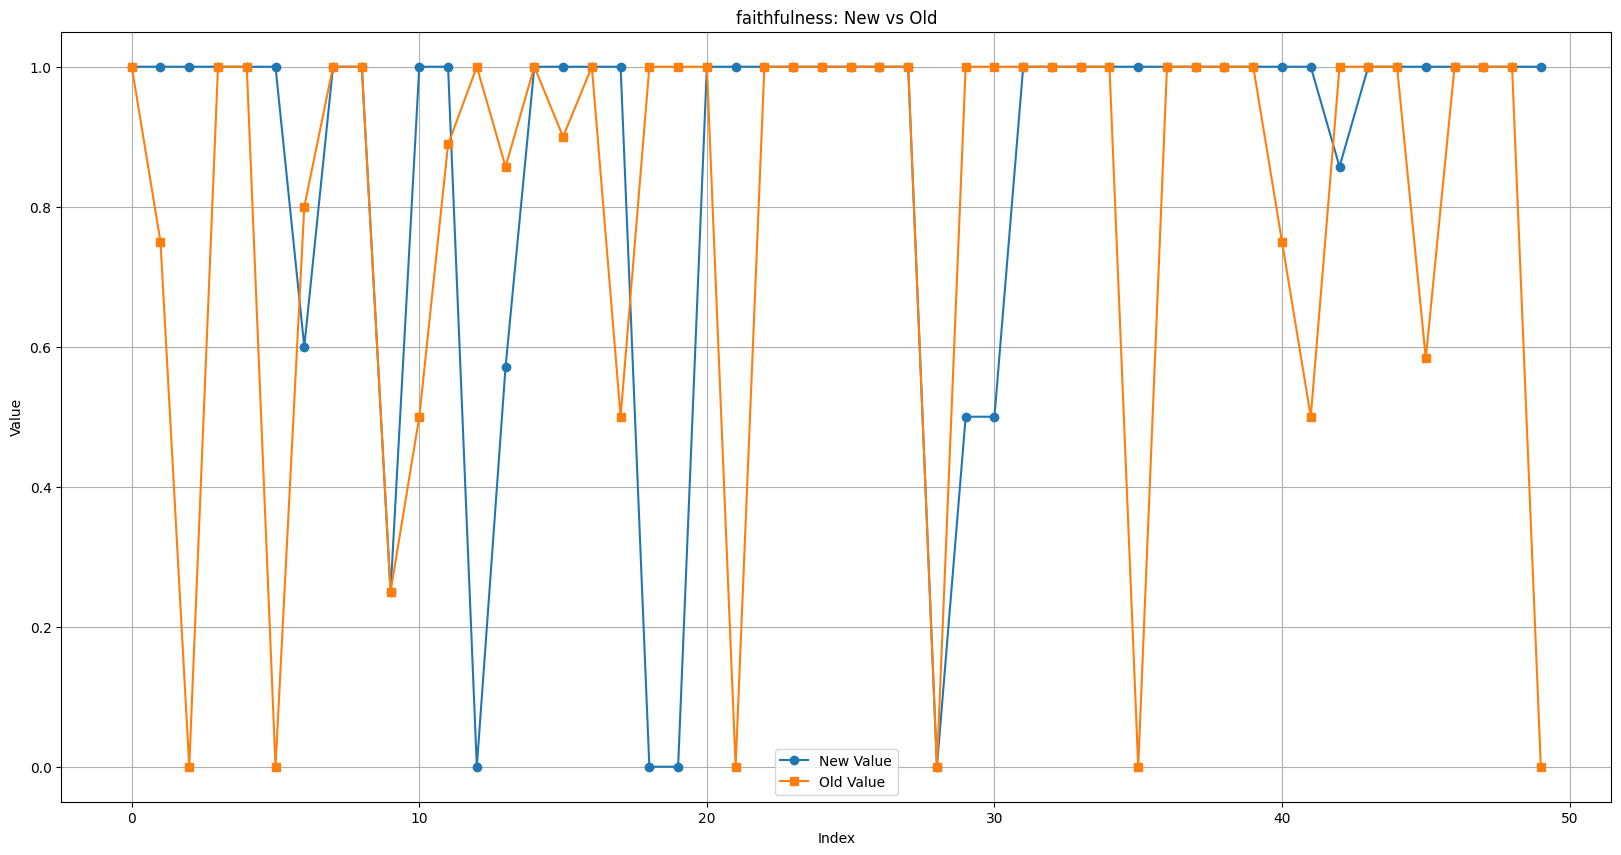

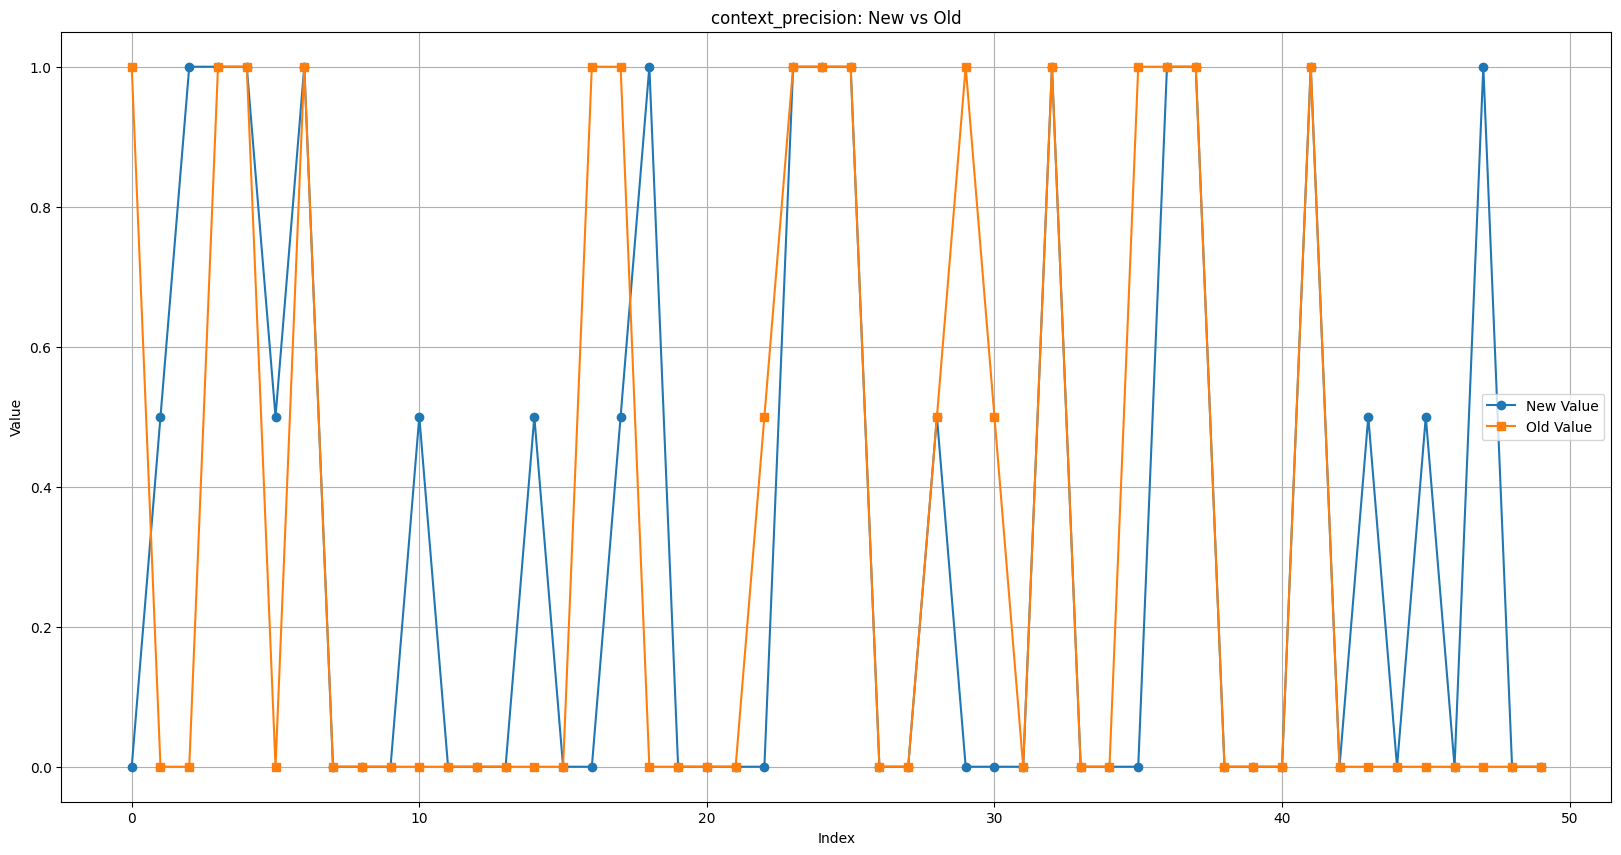

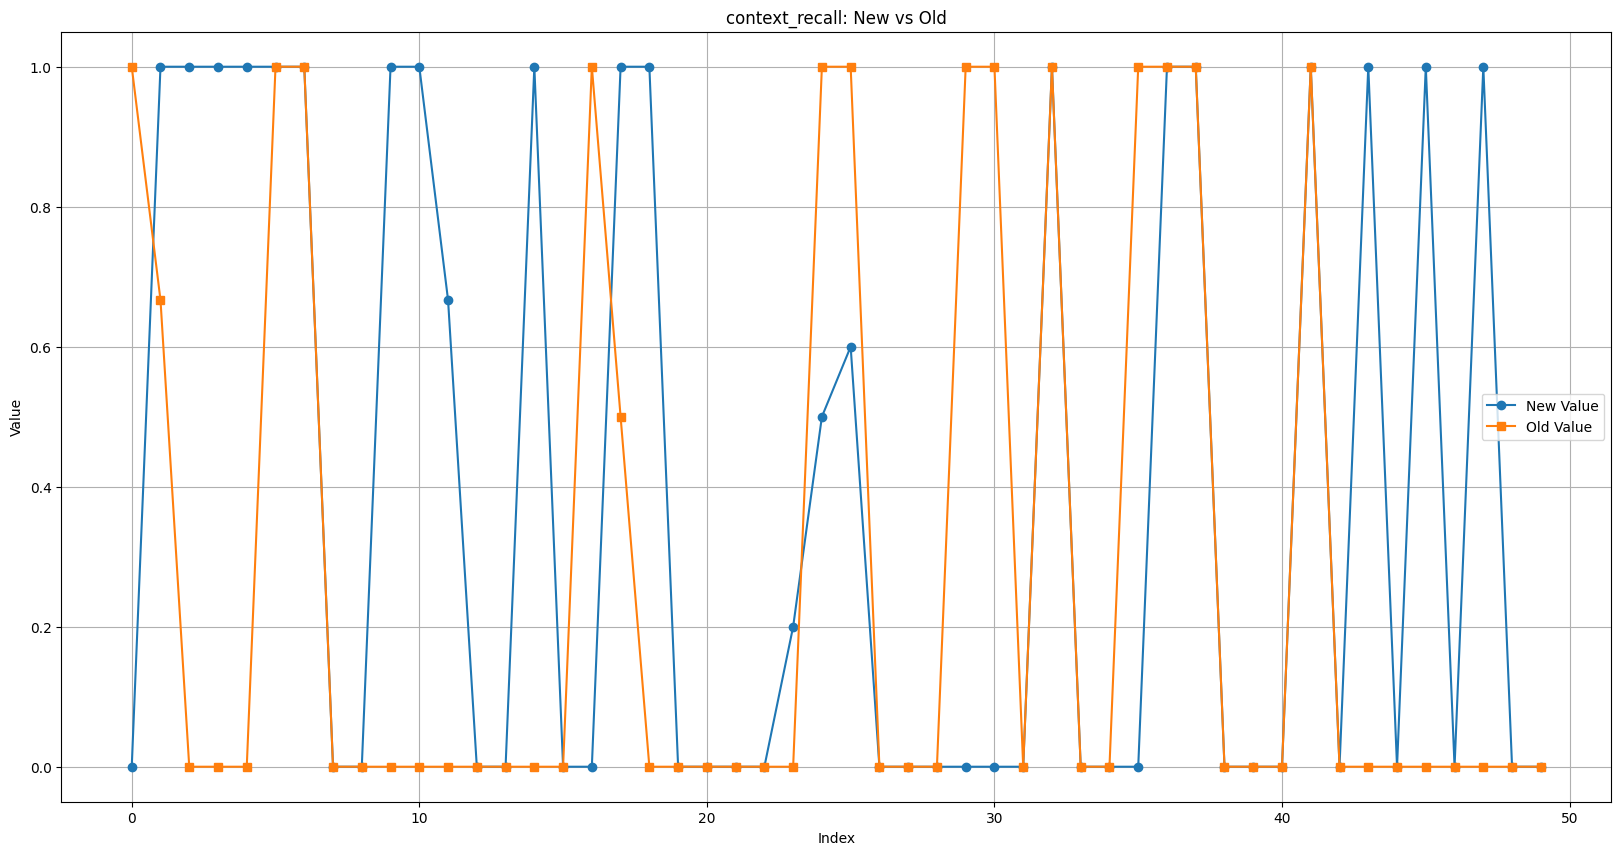

In [68]:
# metric = "context_precision"

for metric in df_old_dataset.columns[4:]:
    plot_a_metric(metric, df_ragas_result, df_old_dataset)

In [85]:
row = 0
for i, col in enumerate(df_ragas_result.columns):
    if i != 1:
        print("\n\n"+col+": \n"+str(df_ragas_result.iloc[row, i]))



user_input: 
What is the objective of the Carbon Call initiative?


response: 
The objective of the Carbon Call initiative is not explicitly mentioned in the provided information.


reference: 
The objective of Carbon Call is to unify the world around a carbon accounting system that is more reliable and interoperable


faithfulness: 
1.0


context_precision: 
0.0


context_recall: 
0.0


In [88]:
for context in df_ragas_result.iloc[row,1]:
    print("\n\n"+context)




## Page 22

```markdown
# Technical Analysis Report: Carbon Removal Initiatives

## Extracted Text

### Title: Removing Carbon
> "We are three years into our mission to build the carbon dioxide removal (CDR) capacity that the world will require to prevent the worst effects of climate change."

---

### **Our Focus**
1. **Nascent, high-quality solutions** that need early support to scale.
2. **Mature proposals** for large-scale projects (e.g., >500,000 metric tons/year).
3. **Financial institutions** ready to provide or ensure project-level lending against credit-worthy offtakes.
4. **Other buyers** ready to syndicate offtakes to assure capacity gets built.
5. **Insurance and assurance** (e.g., independent MRV) and performance-guarantee players across CDR approaches.

---

### **Offtake Agreements**
- **Overview**: Over the past 18 months, Microsoft has developed processes and structures to create long-term carbon removal offtake agreements. These agreements are designed to address qu